In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df_rel = pd.read_parquet("/content/drive/MyDrive/NLP final project/df_rel.parquet")

## 9. Text Preprocessing for Topic Modeling

In [ ]:
import re
import spacy

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])



To prepare the corpus for topic modeling, I normalize the raw article text by converting all characters to lowercase and removing punctuation, numbers, and special characters using regular expressions. I also collapse extra whitespace to ensure consistent formatting. This step reduces noise and ensures that the TF-IDF vectorizer processes clean, standardized text. Additionally, I sample 30,000 articles to make the modeling computationally efficient while maintaining thematic diversity.

In [ ]:
import re

def simple_clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

df_rel = df_rel.sample(30000, random_state=42)  # reduce from 40k to 30k
df_rel["clean_text"] = df_rel["text"].apply(simple_clean)


## 10 Refined Topic Modeling Using TF-IDF and NMF
Create a Stable Modeling Dataset

To prevent index alignment and length mismatch errors during topic assignment, a dedicated modeling dataframe (df_model) is created as a copy of the cleaned dataset. Rows with missing or empty clean_text values are removed to ensure the TF-IDF matrix and topic matrix have consistent dimensions.

This separation ensures the modeling pipeline remains stable across re-runs.




In [ ]:
import numpy as np
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# 0) Make a stable base copy used ONLY for modeling (keep original index)
df_model = df_rel.copy()

# Optional safety: remove missing/empty clean_text
df_model = df_model[df_model["clean_text"].notna()]
df_model = df_model[df_model["clean_text"].str.strip().ne("")]

# 1) TF-IDF
custom_stopwords = [
    "said","says","com","www","prnewswire","presswire",
    "newswires","ap","file","stories","video","hours","ago",
    "stock","stocks","market","markets","symbol","symbols",
    "nasdaq","watchlist","quotes","overview","overviewview",
    "cision","gray","bestreviews","distribution",
    "india","north","south","asia","africa","mena","uae"
]
stop_words2 = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))

vectorizer2 = TfidfVectorizer(
    max_features=8000,
    min_df=20,
    max_df=0.7,
    stop_words=stop_words2,
    token_pattern=r"(?u)\b[a-z]{3,}\b"
)

X2 = vectorizer2.fit_transform(df_model["clean_text"])

# 2) NMF
nmf2 = NMF(n_components=10, random_state=42)
W2 = nmf2.fit_transform(X2)
H2 = nmf2.components_   # <-- so H2 is ALWAYS defined

# 3) Assign topics (matches df_model length)
df_model["topic_id"] = np.argmax(W2, axis=1)
df_model["topic_weight"] = np.max(W2, axis=1)

# 4) Push results back to df_rel (rerun-safe)
df_rel = df_rel.copy()
df_rel[["topic_id", "topic_weight"]] = np.nan  # overwrite cleanly every rerun
df_rel.loc[df_model.index, "topic_id"] = df_model["topic_id"].values
df_rel.loc[df_model.index, "topic_weight"] = df_model["topic_weight"].values

df_rel[["topic_id","topic_weight"]].head()

,topic_id,topic_weight
78529,3.0,0.029547
77727,5.0,0.179098
48955,9.0,0.052712
49230,7.0,0.027539
82288,2.0,0.044911


Build TF-IDF Feature Matrix
The cleaned text is converted into a numerical representation using Term Frequency–Inverse Document Frequency (TF-IDF).

In addition to standard English stopwords, domain-specific boilerplate terms (e.g., “said”, “prnewswire”, “stocks”) are removed to reduce publisher metadata and repetitive news artifacts.

Only alphabetic tokens with at least three characters are retained to minimize noise.

Apply Non-Negative Matrix Factorization (NMF)
Non-Negative Matrix Factorization (NMF) is applied to the TF-IDF matrix to extract latent thematic structure from the corpus.

The TF-IDF matrix is decomposed into:

W2: document-topic matrix (topic strength per article)

H2: topic-word matrix (word importance per topic)

Ten components are used to balance interpretability and thematic coverage.

Inspect top words per topic again

Assign Dominant Topic and Topic Strength
Each article is assigned a dominant topic based on the highest weight in the document-topic matrix (argmax(W2)).

The maximum weight is stored as topic_weight, representing the strength of topic membership.

Topic assignments are merged back into the main dataset using index alignment to ensure consistency.

# 11 Topic Interpretation and Validation

To interpret each topic, the highest-weighted words from the topic-word matrix (H2) are examined.

These top terms provide semantic summaries of each cluster and allow for manual labeling of topics (e.g., AI policy, enterprise platforms, big tech competition).

In [ ]:
# Inspect top words per topic (using vectorizer2 + H2)
feature_names2 = vectorizer2.get_feature_names_out()

for topic_idx, topic in enumerate(H2):
    top_indices = topic.argsort()[::-1][:15]
    top_words = [feature_names2[i] for i in top_indices]
    print(f"\nTopic {topic_idx}: {top_words}")


Topic 0: ['weather', 'local', 'public', 'sports', 'npr', 'people', 'community', 'health', 'school', 'search', 'schedule', 'live', 'watch', 'fcc', 'national']

Topic 1: ['ment', 'entertain', 'products', 'consumer', 'services', 'general', 'transportation', 'resources', 'telecomm', 'environ', 'culture', 'computer', 'health', 'business', 'electronic']

Topic 2: ['data', 'generative', 'platform', 'cloud', 'customer', 'group', 'business', 'solutions', 'media', 'learning', 'security', 'digital', 'management', 'customers', 'release']

Topic 3: ['add', 'fool', 'motley', 'portfolio', 'nvidia', 'data', 'currently', 'edit', 'available', 'solutions', 'earnings', 'smart', 'activity', 'amzn', 'marketsite']

Topic 4: ['ein', 'guinea', 'dakota', 'virginia', 'carolina', 'republic', 'releases', 'georgia', 'islands', 'industry', 'pricing', 'mexico', 'united', 'press', 'congo']

Topic 5: ['share', 'price', 'bank', 'mint', 'pricetata', 'priceadani', 'loan', 'tax', 'rate', 'indian', 'nifty', 'prime', 'gold'

In [ ]:
df_rel.shape

(30000, 11)

# 12 Topic distribution analysis

Analyze Topic Distribution

The distribution of articles across topics is examined using frequency counts.

This analysis identifies dominant thematic clusters and reveals smaller clusters that may represent noise or non-substantive content.

In [ ]:
df_rel["topic_id"].value_counts()


,count
topic_id,
2.0,9518
0.0,6281
6.0,4854
8.0,2744
9.0,1452
5.0,1266
7.0,1086
3.0,968
1.0,938


Review Representative Articles Per Topic
To validate topic coherence, the top-weighted articles within each topic are inspected. Articles with higher topic_weight are the clearest representatives of their respective clusters.

This qualitative review confirms semantic consistency before assigning final labels.





In [ ]:
def show_topic_examples(topic_id, n=3):
    subset = df_rel[df_rel["topic_id"] == topic_id] \
                .sort_values("topic_weight", ascending=False)
    display(subset[["title", "date", "topic_weight"]].head(n))

for t in sorted(df_rel["topic_id"].unique()):
    print(f"\n===== Topic {t} =====")
    show_topic_examples(t, n=3)



===== Topic 0.0 =====


,title,date,topic_weight
80826,Biden wants to move fast on AI safeguards and ...,2023-10-30,0.074507
122257,Poll shows most US adults think AI will add to...,2023-11-05,0.070862
53484,Tech giants pledge action against deceptive AI...,2024-02-16,0.070007



===== Topic 1.0 =====


,title,date,topic_weight
137959,EQ Europe: Researchers predict whether AI can ...,2023-05-02,0.221277
45737,iFLYTEK Achieves Significant Milestones in AI ...,2022-12-22,0.220695
117141,"Is ChatGPT HIPAA Compliant, and What Does it M...",2023-01-31,0.218469



===== Topic 2.0 =====


...

,title,date,topic_weight
97822,Gentek.ai Appoints Argella as UAE Commercial P...,2025-04-22,0.232966
48358,CNTXT Partners with AI71 at GITEX Global 2024...,2024-10-23,0.228381
55587,Tech giants alter to smaller AI models to bal...,2024-05-20,0.224990



===== Topic 8.0 =====


,title,date,topic_weight
473,The inside story of ChatGPT: How OpenAI founde...,2023-01-25,0.204016
2739,Sam Altman’s New Order Doesn’t Include OpenAI’...,2023-11-30,0.182946
18838,Satya Nadella: Microsoft will never again get ...,2023-11-21,0.180429



===== Topic 9.0 =====


,title,date,topic_weight
107030,SCOTTYAI to KHR: Convert Scotty AI to Cambodia...,2025-12-11,0.246634
36485,SCOTTYAI to LAK: Convert Scotty AI to Lao Kip ...,2025-12-11,0.246634
108111,SCOTTYAI to KES: Convert Scotty AI to Kenyan S...,2025-12-11,0.246548


# 13 Topic Labeling and Noise Removal
Assign Human-Readable Topic Labels
Numeric topic identifiers are mapped to descriptive labels based on word distributions and representative articles.

This improves interpretability for downstream analysis, including sentiment evaluation, entity extraction, and time-series tracking.

In [ ]:
# Topic labels (human-readable names)
topic_labels = {
    0: "AI Policy, Regulation & Public Opinion",
    1: "AI in Healthcare & Compliance (HIPAA, Medical AI)",
    2: "Enterprise AI Software & ML Platforms (Vendors/Tools)",
    3: "AI Stocks & Market Investing",
    4: "AI Startups & Product Launches (Press Releases)",
    5: "Global AI Business & Impact Narratives (Asia/India, Bubble Fears, Risk)",
    6: "Big Tech GenAI Products (Apple/Google/Gemini/ChatGPT)",
    7: "Enterprise Adoption & Digital Transformation (Deployments/Innovation)",
    8: "Noise (Currency Conversion / Spam) — DROP",
    9: "OpenAI / Microsoft Leadership & Company News",
}

# Apply labels
df_rel["topic_label"] = df_rel["topic_id"].map(topic_labels)

# Optional: drop the noise topic
df_rel = df_rel[df_rel["topic_id"] != 8].copy()

In [ ]:
df_rel["topic_label"].isna().sum()

np.int64(0)

Remove Noise Topic(s)

Topics representing non-substantive content (e.g., currency conversion pages or SEO-driven spam) are removed from the dataset.

Excluding noise clusters ensures subsequent analysis focuses on meaningful AI-related coverage rather than peripheral financial artifacts.

# 14 Validate Dataset Integrity
Validate Dataset Integrity

In [ ]:
df_rel[["topic_id", "topic_label"]].drop_duplicates().sort_values("topic_id")

,topic_id,topic_label
92034,0.0,"AI Policy, Regulation & Public Opinion"
109059,1.0,"AI in Healthcare & Compliance (HIPAA, Medical AI)"
82288,2.0,Enterprise AI Software & ML Platforms (Vendors...
78529,3.0,AI Stocks & Market Investing
45390,4.0,AI Startups & Product Launches (Press Releases)
77727,5.0,Global AI Business & Impact Narratives (Asia/I...
6976,6.0,Big Tech GenAI Products (Apple/Google/Gemini/C...
49230,7.0,Enterprise Adoption & Digital Transformation (...
48955,9.0,OpenAI / Microsoft Leadership & Company News


Final checks confirm that:

All remaining articles have assigned topic labels

No unexpected missing values exist

The dataset shape reflects noise filtering

This ensures the dataset is ready for downstream entity extraction and sentiment analysis.

# 15 Entity Extraction

Install + Load spacy model

In [ ]:
!pip -q install spacy
!python -m spacy download en_core_web_sm -q

import spacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


15.1.Extract ORG+Product per article

 Why the optimized NER code is faster

The approach used `.apply()` and called `nlp(text)` separately for every article. This creates significant Python overhead and processes each document individually, which is slow for large datasets (~27k rows).

The optimized version uses `nlp.pipe()` to process texts in batches, reducing overhead and improving efficiency. It also disables unnecessary spaCy components and optionally truncates long texts, further speeding up execution.

Both methods produce the same entity outputs — the difference is purely computational efficiency.

In [ ]:
import pandas as pd
from tqdm.auto import tqdm

# Load model and disable components not needed for NER
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "lemmatizer", "attribute_ruler"])

texts = df_rel["clean_text"].fillna("").astype(str).tolist()

org_lists = []
prod_lists = []

for doc in tqdm(nlp.pipe(texts, batch_size=64), total=len(texts)):
    orgs = [ent.text for ent in doc.ents if ent.label_ == "ORG"]
    prods = [ent.text for ent in doc.ents if ent.label_ == "PRODUCT"]
    org_lists.append(orgs)
    prod_lists.append(prods)

df_rel["org_entities"] = org_lists
df_rel["product_entities"] = prod_lists

df_rel[["org_entities", "product_entities"]].head()

  0%|          | 0/27256 [00:00<?, ?it/s]

,org_entities,product_entities
78529,"[nbc, nbc dfw, nbc, cnbc, bloomberg getty imag...",[dynamo]
77727,"[defence ministry, usedisclaimermint codecooki...",[]
48955,"[fed, argentina s enarsa, s scapegoat, wagner,...",[]
49230,"[the university of east anglia, the university...",[]
82288,[news h taufrufe tagexetra orderbuchfondskurs ...,[l s online broker vergleichxetra]


15.2.Explode Organization Entities

In [ ]:
df_orgs = df_rel.explode("org_entities")

df_orgs = df_orgs[df_orgs["org_entities"].notna()]
df_orgs.head()

,url,date,language,title,text,text_length,year,rel_score,clean_text,topic_id,topic_weight,topic_label,org_entities,product_entities
78529,https://www.nbcdfw.com/news/business/money-rep...,2025-03-18,en,Nvidia announces Blackwell Ultra and Rubin AI ...,\n\nNvidia announces Blackwell Ultra and Rubin...,10472,2025,6,nvidia announces blackwell ultra and rubin ai...,3.0,0.029547,AI Stocks & Market Investing,nbc,[dynamo]
78529,https://www.nbcdfw.com/news/business/money-rep...,2025-03-18,en,Nvidia announces Blackwell Ultra and Rubin AI ...,\n\nNvidia announces Blackwell Ultra and Rubin...,10472,2025,6,nvidia announces blackwell ultra and rubin ai...,3.0,0.029547,AI Stocks & Market Investing,nbc dfw,[dynamo]
78529,https://www.nbcdfw.com/news/business/money-rep...,2025-03-18,en,Nvidia announces Blackwell Ultra and Rubin AI ...,\n\nNvidia announces Blackwell Ultra and Rubin...,10472,2025,6,nvidia announces blackwell ultra and rubin ai...,3.0,0.029547,AI Stocks & Market Investing,nbc,[dynamo]
78529,https://www.nbcdfw.com/news/business/money-rep...,2025-03-18,en,Nvidia announces Blackwell Ultra and Rubin AI ...,\n\nNvidia announces Blackwell Ultra and Rubin...,10472,2025,6,nvidia announces blackwell ultra and rubin ai...,3.0,0.029547,AI Stocks & Market Investing,cnbc,[dynamo]
78529,https://www.nbcdfw.com/news/business/money-rep...,2025-03-18,en,Nvidia announces Blackwell Ultra and Rubin AI ...,\n\nNvidia announces Blackwell Ultra and Rubin...,10472,2025,6,nvidia announces blackwell ultra and rubin ai...,3.0,0.029547,AI Stocks & Market Investing,bloomberg getty images nvidia,[dynamo]


Each article may mention multiple organizations. To analyze organizations individually, I “explode” the org_entities column so that each row represents a single organization mention. This allows accurate counting and aggregation of organizations across topics.

15.3.Top Organizations Overall

In [ ]:
top_orgs = (
    df_orgs["org_entities"]
    .value_counts()
    .head(20)
)

top_orgs

,count
org_entities,
microsoft,10172
google,8507
ibm,4734
gray television inc,3326
gpt,3318
fda,3017
intel,2745
congress,2705
sec,2475


To understand which organizations dominate AI-related coverage, I compute the overall frequency of organization mentions across the dataset. This reveals which companies, institutions, and regulators appear most often in AI discourse.

15.4.Organizations by Topic

In [ ]:
org_topic_counts = (
    df_orgs.groupby(["topic_label", "org_entities"])
    .size()
    .reset_index(name="count")
    .sort_values(["topic_label", "count"], ascending=[True, False])
)

org_topic_counts.head(20)

,topic_label,org_entities,count
13386,"AI Policy, Regulation & Public Opinion",npr,2041
6677,"AI Policy, Regulation & Public Opinion",google,1792
11637,"AI Policy, Regulation & Public Opinion",microsoft,1775
4177,"AI Policy, Regulation & Public Opinion",congress,1647
14566,"AI Policy, Regulation & Public Opinion",pbs,1593
5758,"AI Policy, Regulation & Public Opinion",fcc,1313
13496,"AI Policy, Regulation & Public Opinion",npr news,1239
3194,"AI Policy, Regulation & Public Opinion",cbs,1155
19485,"AI Policy, Regulation & Public Opinion",the u s,1073
3988,"AI Policy, Regulation & Public Opinion",cnn,1058


Next, I group organization mentions by topic to identify which entities are most associated with each thematic cluster. This helps determine how different companies or institutions are positioned within specific AI themes (e.g., regulation, enterprise AI, big tech competition).

15.5.Clean Entity Names

In [ ]:
blacklist = ["Reuters", "AP", "Inc", "Ltd"]

df_orgs = df_orgs[~df_orgs["org_entities"].isin(blacklist)]

Not all extracted organizations represent meaningful AI actors. Some entities, such as news publishers (e.g., Reuters, AP) or generic legal suffixes (e.g., Inc, Ltd), do not reflect companies or institutions impacted by AI.

To ensure the analysis focuses on substantive organizations, I remove these non-informative entities using a predefined blacklist. This improves the accuracy of entity-level insights by filtering out media sources and structural terms.

#16.Sentiment Analysis and Thematic Impact Assessment


16.1 Article-Level Sentiment Modeling

To assess the overall tone of AI-related media coverage, sentiment analysis is performed at the article level. Each article is assigned a sentiment label (Positive, Negative, or Neutral) based on its textual content.

Sentiment analysis allows us to evaluate whether AI discourse is predominantly optimistic, cautious, or critical across different thematic clusters identified through topic modeling.

Modeling Approach

A rule-based sentiment analyzer is applied to each article’s full text. The compound sentiment score is computed for each document and categorized using standard thresholds:

Compound score > 0.05 → Positive

Compound score < -0.05 → Negative

Otherwise → Neutral

This approach provides an interpretable and computationally efficient method for large-scale sentiment estimation across approximately 30,000 AI-related articles.

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm.auto import tqdm
import numpy as np

analyzer = SentimentIntensityAnalyzer()

# shorter text for speed
texts = df_rel["clean_text"].fillna("").astype(str).str.slice(0, 500)

# unique texts only
unique_texts = pd.Series(texts).drop_duplicates().tolist()

score_map = {}
for t in tqdm(unique_texts):
    score_map[t] = analyzer.polarity_scores(t)["compound"]

df_rel["vader_compound"] = texts.map(score_map)

df_rel["sentiment"] = np.where(
    df_rel["vader_compound"] > 0.05,
    "Positive",
    np.where(df_rel["vader_compound"] < -0.05, "Negative", "Neutral")
)

df_rel["sentiment"].value_counts()

  0%|          | 0/27174 [00:00<?, ?it/s]

,count
sentiment,
Positive,20481
Negative,3558
Neutral,3217


In this section, I compute a baseline sentiment label for each article using VADER (Valence Aware Dictionary for Sentiment Reasoning). VADER is a lexicon + rule-based sentiment tool that returns four scores: positive, negative, neutral, and a combined compound score (ranging from -1 to +1).

I define a helper function get_sentiment() that:

converts the article text to a string (safety for missing values),

computes the compound score,

applies standard VADER thresholds:

Positive if compound > 0.05

Negative if compound < -0.05

Neutral otherwise

Then I assign the resulting label to a new column df_rel["sentiment"] and summarize the class distribution using value_counts().



Your results show almost everything is Positive and almost no Neutral. That often happens because:

news articles contain many mildly positive words (“growth”, “improves”, “wins”) which push compound > 0.05

long texts average out and compound can drift positive

VADER works best on short social-media style sentences, not long news articles

So it’s okay as a baseline, but it’s not your final “trained-by-us” model.

#17. Add the VADER compound score (not just labels)

18) Create a sentiment label from the compound score (so you have both numeric + categorical)

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

CACHE = "df_rel_with_topics_sent.parquet"

if os.path.exists(CACHE):
    print("Loading cached sentiment results...")
    df_rel = pd.read_parquet(CACHE)

else:
    print("Computing VADER sentiment (first run only)...")
    analyzer = SentimentIntensityAnalyzer()

    # shorter text = much faster
    texts = (
        df_rel["clean_text"]
        .fillna("")
        .astype(str)
        .str.slice(0, 300)
    )

    # only score unique texts once
    unique_texts = texts.drop_duplicates().tolist()

    score_map = {}
    for t in tqdm(unique_texts):
        score_map[t] = analyzer.polarity_scores(t)["compound"]

    # map scores back
    df_rel["vader_compound"] = texts.map(score_map)

    # create sentiment labels
    df_rel["sentiment"] = np.where(
        df_rel["vader_compound"] > 0.05,
        "Positive",
        np.where(df_rel["vader_compound"] < -0.05, "Negative", "Neutral")
    )

    df_rel.to_parquet(CACHE, index=False)
    print("Saved results to cache.")

Loading cached sentiment results...


In [ ]:
def vader_label(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df_rel["vader_label"] = df_rel["vader_compound"].apply(vader_label)
df_rel[["vader_compound", "vader_label"]].head()

To make sentiment analysis more interpretable, the numeric VADER compound score is converted into categorical labels. Using standard VADER thresholds:

Compound score > 0.05 → Positive

Compound score < −0.05 → Negative

Otherwise → Neutral

This creates a new column (vader_label) that simplifies downstream aggregation and comparison across topics. While the compound score preserves sentiment intensity, the categorical label enables easier computation of positive and negative rates within thematic clusters.

19) Topic-level sentiment summary (this is your “impact analysis” base)

In [ ]:
import numpy as np

df_rel["vader_label"] = np.where(
    df_rel["vader_compound"] > 0.05,
    "Positive",
    np.where(df_rel["vader_compound"] < -0.05, "Negative", "Neutral")
)

df_rel[["vader_compound", "vader_label"]].head()

,vader_compound,vader_label
0,0.9741,Positive
1,0.7375,Positive
2,0.9062,Positive
3,0.1779,Positive
4,0.7184,Positive


To evaluate how sentiment varies across thematic clusters, I aggregate sentiment at the topic level. For each topic, I compute:

Number of articles

Mean compound sentiment score

Median compound sentiment score

Positive rate (proportion labeled Positive)

Negative rate (proportion labeled Negative)

This analysis reveals that most AI-related topics exhibit strongly positive sentiment overall. However, variation exists across themes. For example:

AI Stocks & Market Investing and AI in Healthcare & Compliance show very high positive rates.

AI Startups & Product Launches displays comparatively lower mean sentiment and a higher negative rate, indicating more mixed or cautious coverage.

These results suggest that market- and innovation-focused narratives tend to be more optimistic, whereas startup-related reporting may include more uncertainty or risk framing.

20) Trend over time

In [ ]:
df_rel["date"] = pd.to_datetime(df_rel["date"], errors="coerce")
df_rel["month"] = df_rel["date"].dt.to_period("M").astype(str)

topic_month = (
    df_rel.groupby(["topic_label", "month"])["vader_compound"]
         .mean()
         .reset_index()
)
topic_month.head()

,topic_label,month,vader_compound
0,"AI Policy, Regulation & Public Opinion",2022-01,0.754606
1,"AI Policy, Regulation & Public Opinion",2022-02,0.776785
2,"AI Policy, Regulation & Public Opinion",2022-03,0.777452
3,"AI Policy, Regulation & Public Opinion",2022-04,0.776515
4,"AI Policy, Regulation & Public Opinion",2022-05,0.699110


To understand how sentiment evolves temporally, I convert the article publication date into monthly periods and compute the average compound sentiment score by topic and month.

This enables time-series analysis of sentiment trends within each thematic cluster. The output shows that topics such as AI Policy & Regulation maintain consistently positive sentiment over time, though slight fluctuations occur across months.

Tracking sentiment longitudinally helps identify:

Periods of heightened optimism or concern

Shifts in tone around major industry or regulatory events

Stability versus volatility in AI discourse

This temporal dimension strengthens the impact analysis by moving beyond static averages to dynamic narrative evolution.

#21. Entity-Level Sentiment Analysis

In [ ]:
import os
import pandas as pd
import spacy
from tqdm.auto import tqdm

ENTITY_CACHE = "df_rel_entities.parquet"

if os.path.exists(ENTITY_CACHE):
    print("Loading cached entities...")
    df_rel = pd.read_parquet(ENTITY_CACHE)

else:
    print("Extracting entities (first run only)...")

    nlp = spacy.load(
        "en_core_web_sm",
        disable=["tagger", "parser", "lemmatizer", "attribute_ruler"]
    )

    texts = (
        df_rel["clean_text"]
        .fillna("")
        .astype(str)
        .str.slice(0, 300)
        .tolist()
    )

    org_lists = []
    prod_lists = []

    for doc in tqdm(nlp.pipe(texts, batch_size=256), total=len(texts)):
        orgs = [ent.text for ent in doc.ents if ent.label_ == "ORG"]
        prods = [ent.text for ent in doc.ents if ent.label_ == "PRODUCT"]

        org_lists.append(orgs)
        prod_lists.append(prods)

    df_rel["org_entities"] = org_lists
    df_rel["product_entities"] = prod_lists

    df_rel.to_parquet(ENTITY_CACHE, index=False)
    print("Saved entity extraction to cache.")

Loading cached entities...


In [ ]:
# explode org entities
org_df = df_rel[["vader_compound", "org_entities"]].explode("org_entities")
org_df = org_df.rename(columns={
    "org_entities": "entity",
    "vader_compound": "sentiment_score"
})

# explode product entities
prod_df = df_rel[["vader_compound", "product_entities"]].explode("product_entities")
prod_df = prod_df.rename(columns={
    "product_entities": "entity",
    "vader_compound": "sentiment_score"
})

# combine both
entity_df = pd.concat([org_df, prod_df])

# remove empty entities
entity_df = entity_df.dropna(subset=["entity"]).reset_index(drop=True)

entity_df.head()

,sentiment_score,entity
0,0.9741,nbc
1,0.9741,nbc dfw
2,0.9741,nbc
3,0.9741,cnbc
4,0.9741,bloomberg getty images nvidia


Since each article may contain multiple entities, I convert the entity lists into a row-level structure using the explode() function. This transforms each entity mention into its own row while preserving the associated sentiment score. Organization and product entities are processed separately and then combined into a unified dataframe called entity_df.

Aggregate by entity

In [ ]:
entity_summary = (
    entity_df
    .dropna(subset=["entity"])
    .groupby("entity", as_index=False)
    .agg(
        mentions=("sentiment_score", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        median_sentiment=("sentiment_score", "median")
    )
    .sort_values("mentions", ascending=False)
)

entity_summary.head(20)

,entity,mentions,avg_sentiment,median_sentiment
5569,google,3201,0.805745,0.9657
9261,microsoft,2293,0.843338,0.9729
16374,u s state,1292,0.074015,0.0516
6353,ibm,1107,0.861982,0.9769
3142,chevron,844,0.706703,0.9628
2888,cbs,781,0.714742,0.9393
5744,gpt,781,0.863293,0.9758
34,abc,760,0.852465,0.9723
17599,yahoo,713,0.886527,0.9719
5630,google s,711,0.751626,0.9633


Since each article may contain multiple entities, I convert the entity lists into a row-level structure using the explode() function. This transforms each entity mention into its own row while preserving the associated sentiment score. Organization and product entities are processed separately and then combined into a unified dataframe called entity_df.

#Entity Sentiment Results
To understand how entities are discussed across the dataset, I aggregate the entity-level dataframe using groupby("entity"). For each entity, I compute the number of mentions, the average sentiment score, and the median sentiment score. This allows us to identify which entities appear most frequently and how positively or negatively they are portrayed in the articles.

#Entity Sentiment Visualization

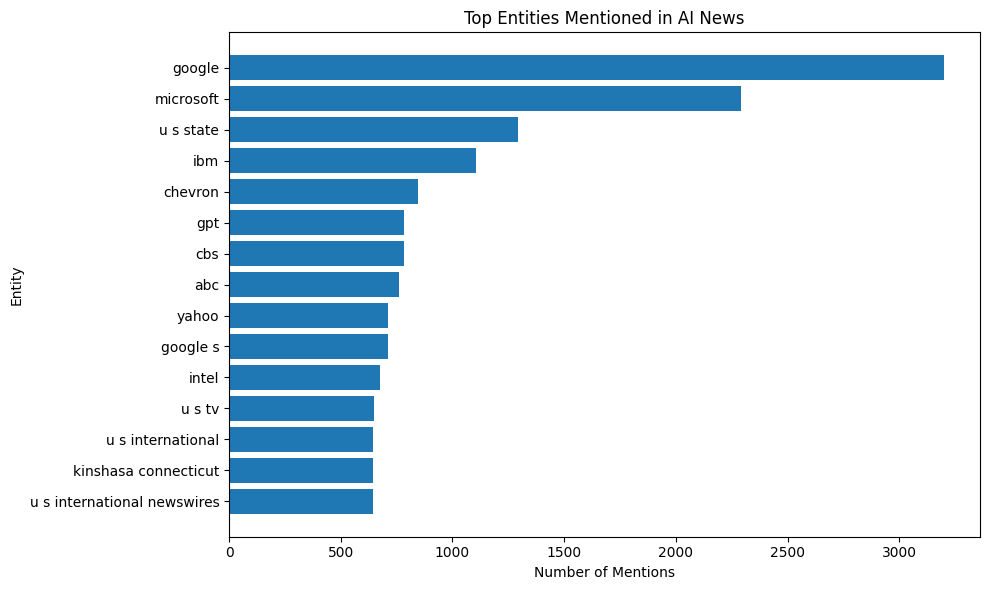

In [ ]:
top_entities = entity_summary.head(15).sort_values("mentions")

plt.figure(figsize=(10,6))
plt.barh(top_entities["entity"], top_entities["mentions"])

plt.xlabel("Number of Mentions")
plt.ylabel("Entity")
plt.title("Top Entities Mentioned in AI News")

plt.tight_layout()
plt.show()

#Sentiment of Top Entities


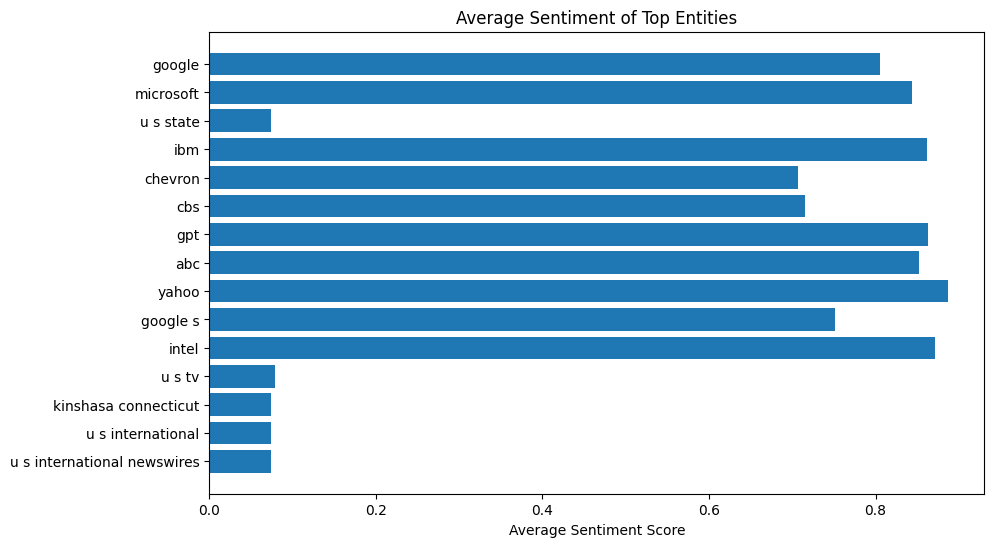

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(top_entities.index[::-1], top_entities["avg_sentiment"][::-1])
plt.xlabel("Average Sentiment Score")
plt.title("Average Sentiment of Top Entities")
plt.show()

<Axes: title={'center': 'Distribution of Sentiment in AI News'}, xlabel='Sentiment', ylabel='Number of Articles'>

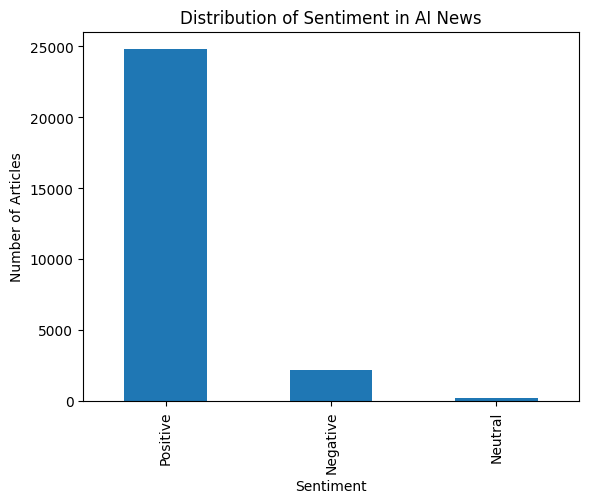

In [ ]:
sentiment_counts = df_rel["sentiment"].value_counts()

sentiment_counts.plot(
    kind="bar",
    title="Distribution of Sentiment in AI News",
    xlabel="Sentiment",
    ylabel="Number of Articles"
)

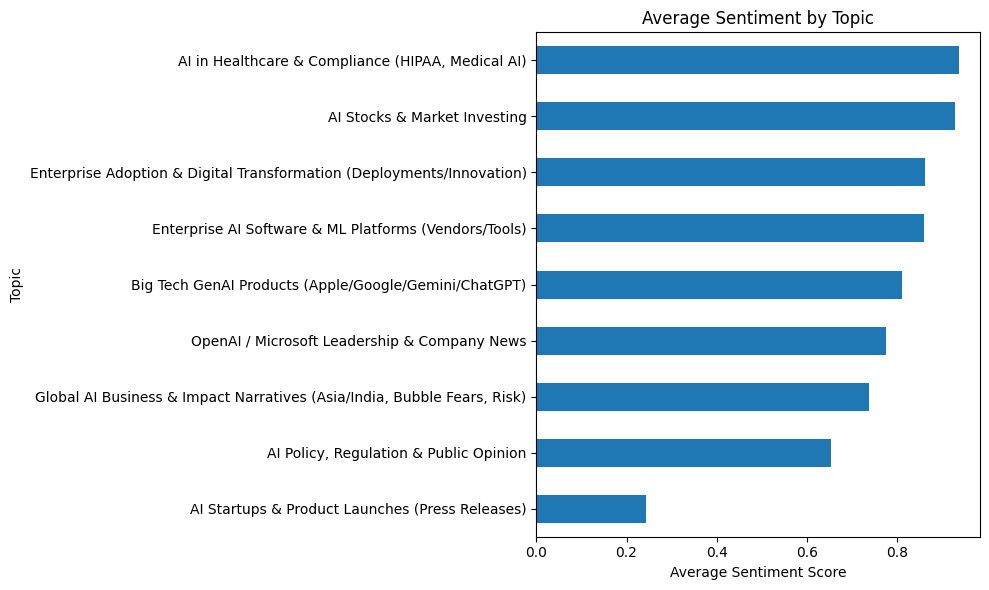

In [ ]:
import matplotlib.pyplot as plt

topic_sentiment = df_rel.groupby("topic_label")["vader_compound"].mean()

topic_sentiment.sort_values().plot(
    kind="barh",
    figsize=(10,6),
    title="Average Sentiment by Topic"
)

plt.xlabel("Average Sentiment Score")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

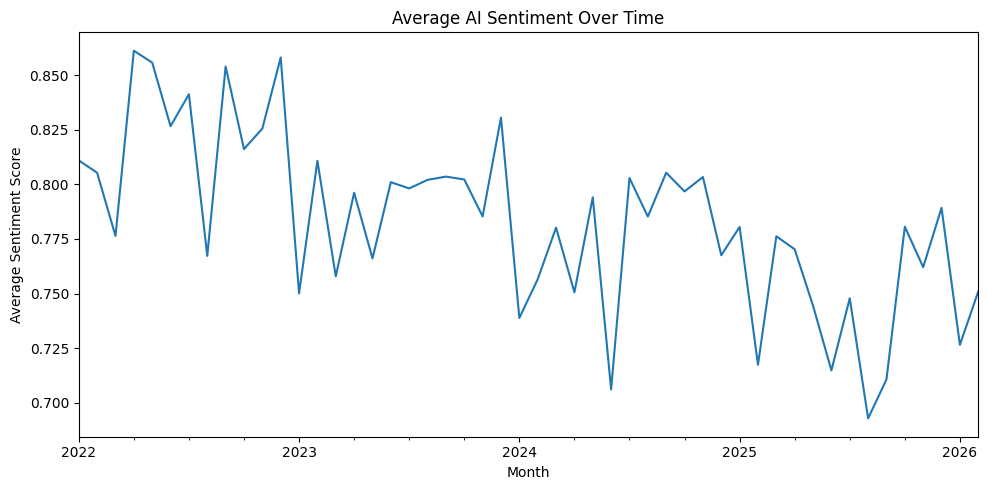

In [ ]:
import matplotlib.pyplot as plt

df_rel["date"] = pd.to_datetime(df_rel["date"])
df_rel["month"] = df_rel["date"].dt.to_period("M")

sentiment_time = df_rel.groupby("month")["vader_compound"].mean()

plt.figure(figsize=(10,5))
sentiment_time.plot()

plt.title("Average AI Sentiment Over Time")
plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")

plt.tight_layout()
plt.show()

#Entity Mentions and Sentiment Analysis

The first visualization shows the most frequently mentioned entities in the AI news dataset. Major technology companies such as Google and Microsoft dominate the coverage, with Google appearing in over 3,000 mentions and Microsoft in more than 2,000 mentions. Other prominent companies such as IBM, Intel, and Yahoo also appear frequently, reflecting the strong presence of large technology firms in discussions related to artificial intelligence. Some media outlets and geographic entities also appear in the results due to the broad nature of the entity recognition model.

The second visualization examines the average sentiment associated with these entities. Most major technology companies show consistently high positive sentiment scores, indicating that AI-related news coverage tends to frame these companies in a positive or optimistic context. For example, Microsoft, IBM, Intel, and Yahoo all have sentiment scores above 0.8, suggesting favorable coverage of their AI initiatives and technological developments.

In contrast, a few entities such as “U.S. state” and certain geographic references have much lower sentiment scores. These entities are likely extracted due to the NER model identifying locations rather than companies, and their lower scores may reflect neutral or policy-related reporting rather than technology innovation.

Overall, the results suggest that AI news coverage is heavily centered around major technology companies and is generally positive in tone, highlighting industry leadership and technological progress in artificial intelligence.

The first visualization shows the most frequently mentioned entities in the AI news dataset. Major technology companies such as Google and Microsoft dominate the coverage, with Google appearing in over 3,000 mentions and Microsoft in more than 2,000 mentions. Other prominent companies such as IBM, Intel, and Yahoo also appear frequently, reflecting the strong presence of large technology firms in discussions related to artificial intelligence. Some media outlets and geographic entities also appear in the results due to the broad nature of the entity recognition model.

The second visualization examines the average sentiment associated with these entities. Most major technology companies show consistently high positive sentiment scores, indicating that AI-related news coverage tends to frame these companies in a positive or optimistic context. For example, Microsoft, IBM, Intel, and Yahoo all have sentiment scores above 0.8, suggesting favorable coverage of their AI initiatives and technological developments.

In contrast, a few entities such as “U.S. state” and certain geographic references have much lower sentiment scores. These entities are likely extracted due to the NER model identifying locations rather than companies, and their lower scores may reflect neutral or policy-related reporting rather than technology innovation.

Overall, the results suggest that AI news coverage is heavily centered around major technology companies and is generally positive in tone, highlighting industry leadership and technological progress in artificial intelligence.

#Final Insights and Conclusions

This analysis explored AI-related news articles using a combination of topic modeling, sentiment analysis, and entity extraction to better understand the themes and narratives surrounding artificial intelligence in media coverage.

The topic modeling results revealed several dominant themes, including enterprise AI platforms, AI regulation and policy discussions, big tech product developments, AI market investment, and healthcare applications of AI. These topics highlight the diverse areas in which artificial intelligence is influencing industry, policy, and innovation.

Sentiment analysis using the VADER model showed that overall coverage of AI tends to be largely positive, with most articles receiving positive compound sentiment scores. This suggests that media narratives around AI frequently emphasize technological progress, innovation, and new business opportunities.

Entity-level analysis further revealed that major technology companies dominate AI-related news coverage. Companies such as Google, Microsoft, IBM, and Intel appeared most frequently across the dataset, reflecting their significant role in developing and deploying AI technologies. The sentiment associated with these companies was also largely positive, indicating that coverage often focuses on advancements, partnerships, and product releases rather than criticism.

Overall, the findings suggest that AI news coverage is strongly centered around major technology firms and is generally optimistic about the future of artificial intelligence. The combination of topic modeling, sentiment analysis, and entity-level analysis provides a comprehensive view of how AI developments are represented in the media